In [55]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import gaussian_kde

import utils

In [56]:
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = "exp2"
data_folder = os.path.join(data_dir, exp)
figure_folder = os.path.join(data_dir, f'{exp}_figures')
os.makedirs(figure_folder, exist_ok=True)

print(data_folder)
print(figure_folder)

/Users/rebekahzhang/data/behavior_data/exp2
/Users/rebekahzhang/data/behavior_data/exp2_figures


In [57]:
# two_colors = plt.cm.viridis(np.linspace(0, 1, 2))
two_colors = ["#ffb400", "#9080ff"]
custom_palette = {'s': two_colors[0], 'l': two_colors[1]}

In [58]:
sessions_training = pd.read_csv(os.path.join(data_folder, f'sessions_training_{exp}.csv'))
sessions_training['period'] = sessions_training['session']//10
trials_training = utils.load_data(os.path.join(data_folder, 'trials_training_analyzed.csv'))

In [59]:
trials_training.keys()

Index(['session_trial_num', 'block_trial_num', 'block_num', 'start_time',
       'end_time', 'bg_drawn', 'bg_length', 'bg_repeats', 'num_bg_licks',
       'miss_trial', 'time_waited', 'time_waited_since_cue_on', 'reward',
       'num_consumption_lick', 'num_pump', 'first_lick', 'last_lick',
       'good_trial', 'time_waited_since_last_lick', 'previous_trial_bg_drawn',
       'previous_trial_bg_length', 'previous_trial_bg_repeats',
       'previous_trial_num_bg_licks', 'previous_trial_first_lick',
       'previous_trial_last_lick', 'previous_trial_time_waited',
       'previous_trial_time_waited_since_cue_on',
       'previous_trial_time_waited_since_last_lick', 'previous_trial_reward',
       'previous_trial_num_consumption_lick', 'previous_trial_miss_trial',
       'bg_length_rolling_mean_5', 'bg_length_rolling_mean_10',
       'bg_repeats_rolling_mean_5', 'bg_repeats_rolling_mean_10',
       'num_bg_licks_rolling_mean_5', 'num_bg_licks_rolling_mean_10',
       'first_lick_rolling_mea

In [60]:
sessions_training.mouse.nunique()
sessions_training.groupby('group')['mouse'].nunique()

group
l    21
s    17
Name: mouse, dtype: int64

# Dataset overview

In [61]:
print(f'{len(sessions_training)} sessions')
print(f'{len(trials_training)} trials')

1928 sessions
687875 trials


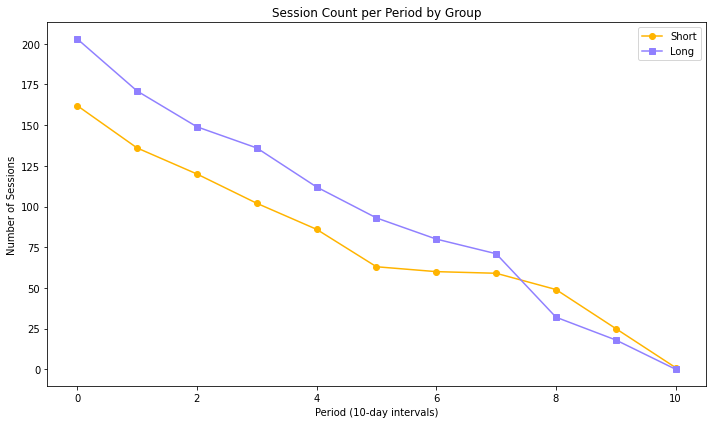

In [62]:
plt.figure(figsize=(10, 6))

session_counts = sessions_training.groupby(['period', 'group']).size().unstack(fill_value=0)
plt.plot(session_counts.index, session_counts['s'], marker='o', label='Short', color=custom_palette['s'])
plt.plot(session_counts.index, session_counts['l'], marker='s', label='Long', color=custom_palette['l'])

plt.xlabel('Period (10-day intervals)')
plt.ylabel('Number of Sessions')
plt.title('Session Count per Period by Group')
plt.legend()  # Add legend

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "session_count_by_period_by_group.png"))

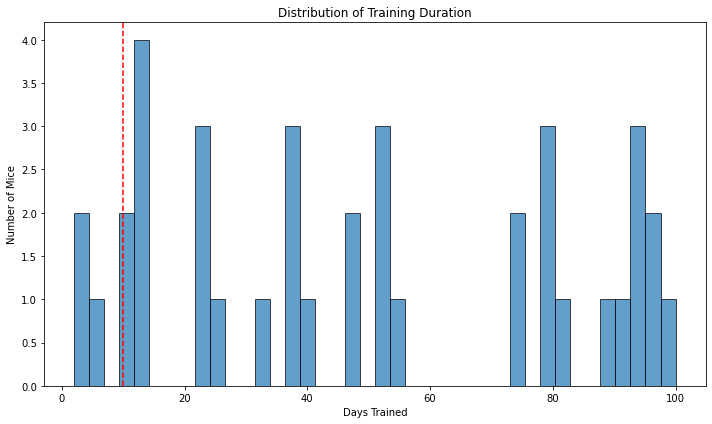

In [63]:
# Get training duration stats
training_duration = sessions_training.groupby('mouse')['session'].max()

plt.figure(figsize=(10, 6))
plt.hist(training_duration, bins=40, alpha=0.7, edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', label='Cutoff (10 sessions)')
plt.xlabel('Days Trained')
plt.ylabel('Number of Mice')
plt.title('Distribution of Training Duration')
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "training_duration_distribution.png"))

### make wait df, 1 row per session

In [64]:
def generate_wait_df(training_session_log):
    wait_df = training_session_log[['mouse', 'session', 'dir', 'group', 'period']].copy()

    for _, session_info in training_session_log.iterrows():
        all_trials = utils.load_data(utils.generate_trials_analyzed_path(data_folder, session_info))
        # time waited for all trials
        tw_mean = all_trials.time_waited.mean()
        tw_med = all_trials.time_waited.median()
        tw_std = all_trials.time_waited.std()

        tw_cue_on_mean = all_trials.time_waited_since_cue_on.mean()
        tw_cue_on_med = all_trials.time_waited_since_cue_on.median()
        tw_cue_on_std = all_trials.time_waited_since_cue_on.std()

        tw_lick_mean = all_trials.time_waited_since_last_lick.mean()
        tw_lick_med = all_trials.time_waited_since_last_lick.median()
        tw_lick_std = all_trials.time_waited_since_last_lick.std()
        
        mask = wait_df["dir"] == session_info["dir"]
        wait_df.loc[mask, [
            "tw_mean", "tw_median", "tw_stdev",
            "tw_cue_on_mean", "tw_cue_on_median", "tw_cue_on_stdev",
            "tw_lick_mean", "tw_lick_median", "tw_lick_stdev",
        ]] = [
            tw_mean, tw_med, tw_std,
            tw_cue_on_mean, tw_cue_on_med, tw_cue_on_std,
            tw_lick_mean, tw_lick_med, tw_lick_std,
        ]

    return wait_df

In [65]:
wait_df = generate_wait_df(sessions_training)

In [66]:
def plot_wait_by_session(wait_df, value_col, ylabel, title, filename, palette, y_max=None):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Calculate mean and std for each group by session
    for group in wait_df['group'].unique():
        group_data = wait_df[wait_df['group'] == group]
        session_stats = group_data.groupby('session')[value_col].agg(['mean', 'std']).reset_index()
        
        ax.plot(session_stats['session'], session_stats['mean'], marker='o', label=group, color=palette[group])
        ax.fill_between(session_stats['session'], 
                    session_stats['mean'] - session_stats['std'],
                    session_stats['mean'] + session_stats['std'],
                    alpha=0.2, color=palette[group])

    ax.set_xlabel('Session')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    if y_max is not None:
        ax.set_ylim(0, y_max)

    plt.tight_layout()
    plt.savefig(os.path.join(figure_folder, filename))

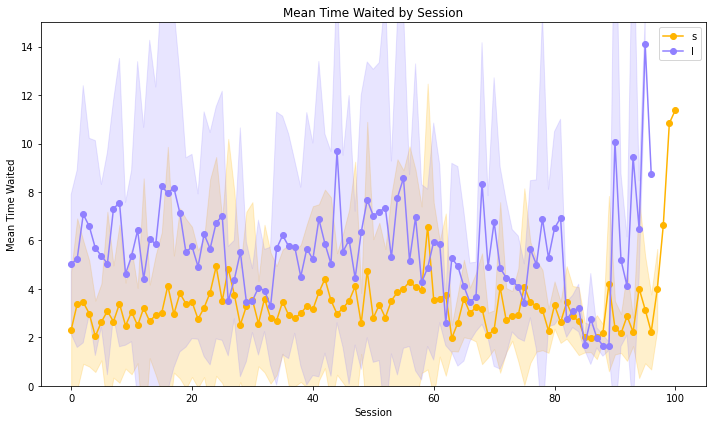

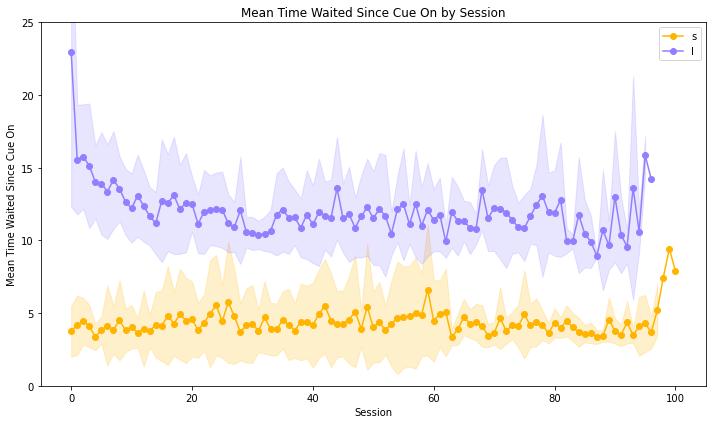

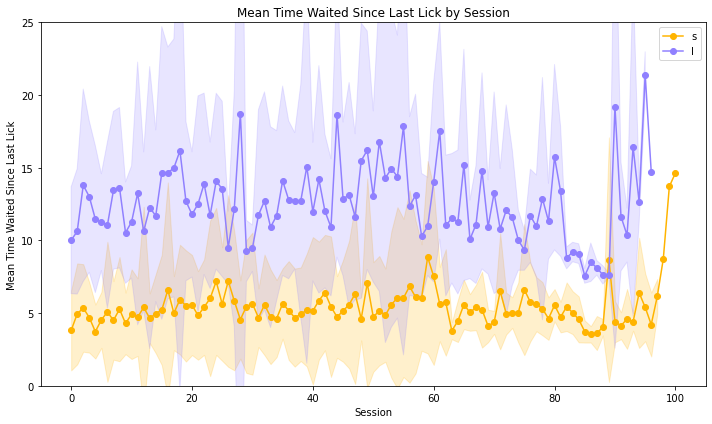

In [67]:
# Time waited
plot_wait_by_session(
    wait_df,
    value_col='tw_mean',
    ylabel='Mean Time Waited',
    title='Mean Time Waited by Session',
    filename='tw_by_session_by_group.png',
    palette=custom_palette,
    y_max=15
)

# Time waited since cue on
plot_wait_by_session(
    wait_df,
    value_col='tw_cue_on_mean',
    ylabel='Mean Time Waited Since Cue On',
    title='Mean Time Waited Since Cue On by Session',
    filename='tw_cue_on_by_session_by_group.png',
    palette=custom_palette,
    y_max=25
)

# Time waited since cue off
plot_wait_by_session(
    wait_df,
    value_col='tw_lick_mean',
    ylabel='Mean Time Waited Since Last Lick',
    title='Mean Time Waited Since Last Lick by Session',
    filename='tw_lick_by_session_by_group.png',
    palette=custom_palette,
    y_max=25
)

# Filter late sessions, early termination mice, outlier mice

### late sessions

In [68]:
session_cap = 80

In [69]:
sessions_training_caped = sessions_training.loc[sessions_training['session'] <= session_cap]
trials_training_caped = trials_training.loc[trials_training['session'] <= session_cap]

print(f'{len(sessions_training_caped)} sessions')
print(f'{len(trials_training_caped)} trials')

1812 sessions
647795 trials


### early termination mice

In [70]:
# Get mice with >= 10 sessions
valid_mice = training_duration[training_duration >= 10].index.tolist()
sessions_training_filtered1 = sessions_training_caped[sessions_training_caped['mouse'].isin(valid_mice)].reset_index(drop=True)
trials_training_filtered1 = trials_training_caped[trials_training_caped['mouse'].isin(valid_mice)].reset_index(drop=True)

print(f'{len(sessions_training_filtered1)} sessions')
print(f'{len(trials_training_filtered1)} trials')


1797 sessions
641415 trials


In [72]:
trials_training_filtered1.keys()

Index(['session_trial_num', 'block_trial_num', 'block_num', 'start_time',
       'end_time', 'bg_drawn', 'bg_length', 'bg_repeats', 'num_bg_licks',
       'miss_trial', 'time_waited', 'time_waited_since_cue_on', 'reward',
       'num_consumption_lick', 'num_pump', 'first_lick', 'last_lick',
       'good_trial', 'time_waited_since_last_lick', 'previous_trial_bg_drawn',
       'previous_trial_bg_length', 'previous_trial_bg_repeats',
       'previous_trial_num_bg_licks', 'previous_trial_first_lick',
       'previous_trial_last_lick', 'previous_trial_time_waited',
       'previous_trial_time_waited_since_cue_on',
       'previous_trial_time_waited_since_last_lick', 'previous_trial_reward',
       'previous_trial_num_consumption_lick', 'previous_trial_miss_trial',
       'bg_length_rolling_mean_5', 'bg_length_rolling_mean_10',
       'bg_repeats_rolling_mean_5', 'bg_repeats_rolling_mean_10',
       'num_bg_licks_rolling_mean_5', 'num_bg_licks_rolling_mean_10',
       'first_lick_rolling_mea

In [71]:
wait_by_session_filted1 = generate_wait_df(sessions_training_filtered1)

### outlier mice

In [73]:
mice_s = sessions_training_filtered1[sessions_training_filtered1['group'] == 's']['mouse'].unique()
mice_l = sessions_training_filtered1[sessions_training_filtered1['group'] == 'l']['mouse'].unique()

s_colors = plt.cm.twilight(np.linspace(0, 1, len(mice_s)))
l_colors = plt.cm.twilight_shifted(np.linspace(0, 1, len(mice_l)))
s_mouse_palette = dict(zip(mice_s, s_colors))
l_mouse_palette = dict(zip(mice_l, l_colors))
mouse_palette = {**s_mouse_palette, **l_mouse_palette}

In [74]:
def plot_wait_by_mouse_by_period(wait_df, value_col, ylabel, filename, mouse_palette, custom_palette):
    """
    Plot wait time metrics by mouse across training periods, separated by group.
    
    Parameters:
    - wait_df: DataFrame with wait data by session
    - value_col: Column name to plot (e.g., 'tw_mean', 'tw_cue_on_mean')
    - ylabel: Y-axis label
    - filename: Output filename for the figure
    - mouse_palette: Dictionary mapping mouse IDs to colors
    - custom_palette: Dictionary mapping groups to colors
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    groups = ['s', 'l']
    titles = [f'Short Group {ylabel} per Period by Mouse', f'Long Group {ylabel} per Period by Mouse']

    for ax, group, title in zip(axes, groups, titles):
        group_df = wait_df[wait_df['group'] == group]
        # Compute mean and std for each mouse and period
        agg = group_df.groupby(['mouse', 'period'], as_index=False).agg(
            value_mean=(value_col, 'mean'),
            value_std=(value_col, 'std'),
            n=(value_col, 'count')
        )
        # Calculate standard error
        agg['value_se'] = agg['value_std'] / np.sqrt(agg['n'])

        mice = agg['mouse'].unique()

        for mouse in mice:
            data = agg[agg['mouse'] == mouse].sort_values('period')
            ax.errorbar(
                data['period'], data['value_mean'], yerr=data['value_se'],
                fmt='-o', color=mouse_palette[mouse], label=mouse, alpha=0.8, lw=1, capsize=3
            )

        ax.set_xlabel('Training Period (10-day intervals)', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.set_xticks(sorted(agg['period'].unique()))
        ax.grid(alpha=0.3)
        ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8, title='Mouse')

    axes[0].set_ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(figure_folder, filename))


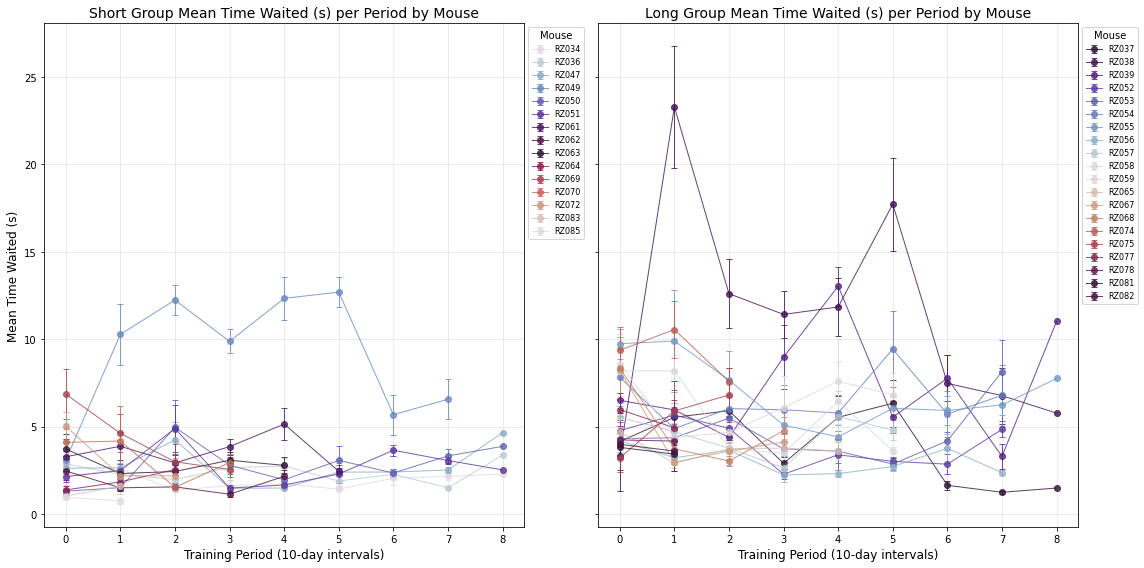

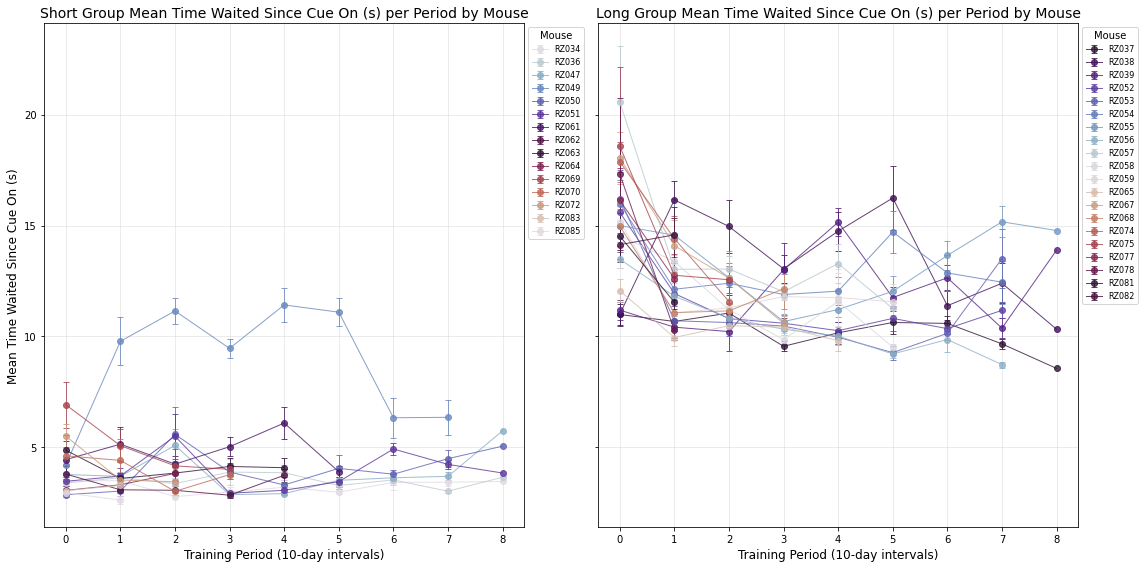

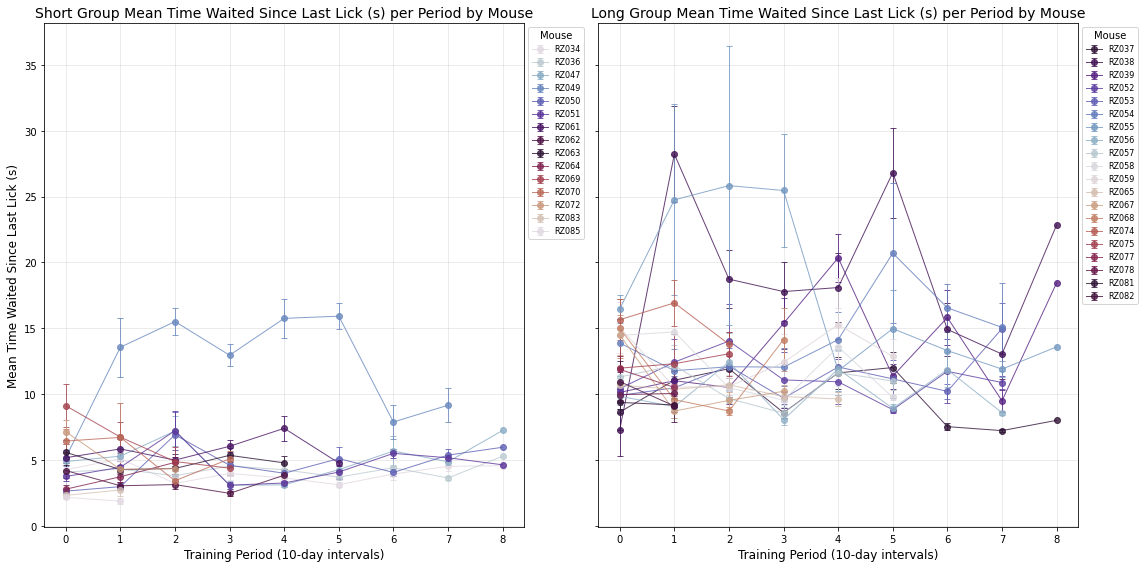

In [75]:
# Plot for time waited
plot_wait_by_mouse_by_period(
    wait_by_session_filted1,
    value_col='tw_mean',
    ylabel='Mean Time Waited (s)',
    filename='tw_by_mouse_by_period_by_group.png',
    mouse_palette=mouse_palette,
    custom_palette=custom_palette
)

# Plot for time waited since cue on
plot_wait_by_mouse_by_period(
    wait_by_session_filted1,
    value_col='tw_cue_on_mean',
    ylabel='Mean Time Waited Since Cue On (s)',
    filename='tw_cue_on_by_mouse_by_period_by_group.png',
    mouse_palette=mouse_palette,
    custom_palette=custom_palette
)

# Plot for time waited since last lick
plot_wait_by_mouse_by_period(
    wait_by_session_filted1,
    value_col='tw_lick_mean',
    ylabel='Mean Time Waited Since Last Lick (s)',
    filename='tw_lick_by_mouse_by_period_by_group.png',
    mouse_palette=mouse_palette,
    custom_palette=custom_palette
)


In [76]:
def generate_mouse_wait_df(wait_df):
    data_list = []
    wait_df_by_mouse = wait_df.groupby('mouse')
    for m, mouse_data in wait_df_by_mouse:
        avg_avg_tw = mouse_data['tw_mean'].mean()
        avg_avg_tw_cue_on = mouse_data['tw_cue_on_mean'].mean()
        avg_avg_tw_lick = mouse_data['tw_lick_mean'].mean()
        data = {
            "mouse": m, 
            'tw': avg_avg_tw,
            'tw_cue_on': avg_avg_tw_cue_on,
            'tw_lick': avg_avg_tw_lick,
            'group': mouse_data.group.tolist()[0]
        }
        data_list.append(data)
    mouse_wait_df = pd.DataFrame(data_list).sort_values(by=['group','tw'])
    return mouse_wait_df

In [77]:
mouse_wait_df = generate_mouse_wait_df(wait_by_session_filted1)
display(mouse_wait_df)

,mouse,tw,tw_cue_on,tw_lick,group
13,RZ056,3.087526,10.625024,10.168750,l
31,RZ081,3.698639,13.672429,9.322973,l
21,RZ065,3.764084,10.682201,10.362075,l
32,RZ082,3.894246,14.236413,10.530652,l
9,RZ052,3.946847,11.442285,11.301780,l
2,RZ037,4.117569,10.389467,9.808335,l
30,RZ078,4.221868,16.147501,9.982609,l
14,RZ057,4.465237,14.155145,10.694115,l
10,RZ053,4.580090,11.360626,11.332203,l
22,RZ067,4.753247,14.009636,10.768158,l


In [78]:
def find_outlier_mice(mouse_wait_df, wait_val, method='iqr', multiplier=3):
    """
    Find outlier mice within each group based on tw values.
    """
    outliers = []
    for group, group_data in mouse_wait_df.groupby('group'):
        tw = group_data[wait_val]
        if method == 'iqr':
            q1, q3 = tw.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
            mask = (tw < lower) | (tw > upper)
        elif method == 'zscore':
            mean, std = tw.mean(), tw.std()
            mask = abs((tw - mean) / std) > multiplier
        else:
            raise ValueError("method must be 'iqr' or 'zscore'")
        for _, row in group_data[mask].iterrows():
            outliers.append({'mouse': row['mouse'], 'group': row['group'], 'tw': row['tw'],
                             'method': method, 'is_outlier': True})
    return pd.DataFrame(outliers)

In [79]:
# Find outliers using IQR method
outliers_iqr_tw = find_outlier_mice(mouse_wait_df, 'tw', method='iqr', multiplier=1.5)
print("Time waited Outliers using IQR method (1.5x IQR):")
print(outliers_iqr_tw)

# Find outliers using z-score method
outliers_zscore_tw = find_outlier_mice(mouse_wait_df, 'tw', method='zscore', multiplier=2.0)
print("\nTime waited Outliers using Z-score method (|z| > 2):")
print(outliers_zscore_tw)

# Find outliers using IQR method
outliers_iqr_cue_on = find_outlier_mice(mouse_wait_df, 'tw_cue_on', method='iqr', multiplier=1.5)
print("\nTime waited since cue on Outliers using IQR method (1.5x IQR):")
print(outliers_iqr_cue_on)

# Find outliers using z-score method
outliers_zscore_cue_on = find_outlier_mice(mouse_wait_df, 'tw_cue_on', method='zscore', multiplier=2.0)
print("\nTime waited since cue on Outliers using Z-score method (|z| > 2):")
print(outliers_zscore_cue_on)

# Find outliers using IQR method
outliers_iqr_lick = find_outlier_mice(mouse_wait_df, 'tw_lick', method='iqr', multiplier=1.5)
print("\nTime waited since last lick Outliers using IQR method (1.5x IQR):")
print(outliers_iqr_lick)

# Find outliers using z-score method
outliers_zscore_lick = find_outlier_mice(mouse_wait_df, 'tw_lick', method='zscore', multiplier=2.0)
print("\nTime waited since last lick Outliers using Z-score method (|z| > 2):")
print(outliers_zscore_lick)

Time waited Outliers using IQR method (1.5x IQR):
   mouse group         tw method  is_outlier
0  RZ038     l  11.731679    iqr        True
1  RZ049     s   9.125444    iqr        True

Time waited Outliers using Z-score method (|z| > 2):
   mouse group         tw  method  is_outlier
0  RZ038     l  11.731679  zscore        True
1  RZ049     s   9.125444  zscore        True

Time waited since cue on Outliers using IQR method (1.5x IQR):
   mouse group        tw method  is_outlier
0  RZ049     s  9.125444    iqr        True

Time waited since cue on Outliers using Z-score method (|z| > 2):
   mouse group        tw  method  is_outlier
0  RZ049     s  9.125444  zscore        True

Time waited since last lick Outliers using IQR method (1.5x IQR):
   mouse group         tw method  is_outlier
0  RZ055     l   6.884181    iqr        True
1  RZ038     l  11.731679    iqr        True
2  RZ049     s   9.125444    iqr        True

Time waited since last lick Outliers using Z-score method (|z| > 2

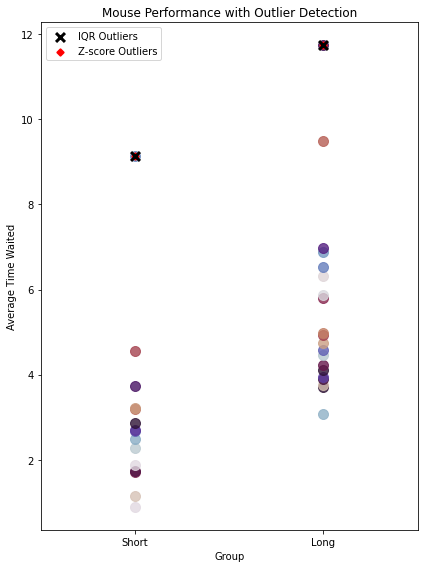

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(6, 8))
group_order = ['s', 'l']
group_labels = ['Short', 'Long']

# Plot all mice
for i, group in enumerate(group_order):
    group_data = mouse_wait_df[mouse_wait_df['group'] == group]
    for _, mouse_row in group_data.iterrows():
        ax.scatter(i, mouse_row['tw'],
                   color=mouse_palette[mouse_row['mouse']],
                   alpha=0.8, s=100, zorder=1)

# Mark outliers with different markers
for i, group in enumerate(group_order):
    group_data = mouse_wait_df[mouse_wait_df['group'] == group]
    
    # IQR outliers (X marker)
    iqr_outliers = outliers_iqr_tw[outliers_iqr_tw['group'] == group]['mouse'].tolist()
    iqr_data = group_data[group_data['mouse'].isin(iqr_outliers)]
    ax.scatter([i] * len(iqr_data), iqr_data['tw'],
                color='k', s=80, marker='x', linewidth=3,
                label='IQR Outliers' if group == 's' else "", zorder=3)
    
    # Z-score outliers (diamond marker)
    zscore_outliers = outliers_zscore_tw[outliers_zscore_tw['group'] == group]['mouse'].tolist()
    zscore_data = group_data[group_data['mouse'].isin(zscore_outliers)]
    ax.scatter([i] * len(zscore_data), zscore_data['tw'],
                color='red', s=20, marker='D', linewidth=2,
                label='Z-score Outliers' if group == 's' else "", zorder=2)

ax.set_xlabel('Group')
ax.set_ylabel('Average Time Waited')
ax.set_title('Mouse Performance with Outlier Detection')
ax.set_xticks([0, 1])
ax.set_xticklabels(group_labels)
ax.set_xlim(-0.5, 1.5)
ax.legend(loc='best')

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "outlier_mouse_comparison_iqr_zscore.png"))

In [81]:
outlier_mice = outliers_iqr_tw['mouse'].tolist()

In [82]:
sessions_training_filtered2 = sessions_training_filtered1[~sessions_training_filtered1['mouse'].isin(outlier_mice)]
trials_training_filtered2 = trials_training_filtered1[~trials_training_filtered1['mouse'].isin(outlier_mice)]
wait_by_session_filted2 = wait_by_session_filted1[~wait_by_session_filted1['mouse'].isin(outlier_mice)]

print(f'{len(sessions_training_filtered2)} sessions')
print(f'{len(trials_training_filtered2)} trials')

1637 sessions
604922 trials


In [83]:
trials_training_filtered2.keys()

Index(['session_trial_num', 'block_trial_num', 'block_num', 'start_time',
       'end_time', 'bg_drawn', 'bg_length', 'bg_repeats', 'num_bg_licks',
       'miss_trial', 'time_waited', 'time_waited_since_cue_on', 'reward',
       'num_consumption_lick', 'num_pump', 'first_lick', 'last_lick',
       'good_trial', 'time_waited_since_last_lick', 'previous_trial_bg_drawn',
       'previous_trial_bg_length', 'previous_trial_bg_repeats',
       'previous_trial_num_bg_licks', 'previous_trial_first_lick',
       'previous_trial_last_lick', 'previous_trial_time_waited',
       'previous_trial_time_waited_since_cue_on',
       'previous_trial_time_waited_since_last_lick', 'previous_trial_reward',
       'previous_trial_num_consumption_lick', 'previous_trial_miss_trial',
       'bg_length_rolling_mean_5', 'bg_length_rolling_mean_10',
       'bg_repeats_rolling_mean_5', 'bg_repeats_rolling_mean_10',
       'num_bg_licks_rolling_mean_5', 'num_bg_licks_rolling_mean_10',
       'first_lick_rolling_mea

In [85]:
means = trials_training_filtered2.groupby('group')['time_waited'].mean()
print("Short tw mean:", means.get('s', float('nan')))
print("Long tw mean:", means.get('l', float('nan')))

means_cue_on = trials_training_filtered2.groupby('group')['time_waited_since_cue_on'].mean()
print("\nShort tw_cue_on mean:", means_cue_on.get('s', float('nan')))
print("Long tw_cue_on mean:", means_cue_on.get('l', float('nan')))  

means_lick = trials_training_filtered2.groupby('group')['time_waited_since_last_lick'].mean()
print("\nShort tw_lick mean:", means_lick.get('s', float('nan')))
print("Long tw_lick mean:", means_lick.get('l', float('nan')))

Short tw mean: 2.1759666700023215
Long tw mean: 4.365985557621982

Short tw_cue_on mean: 3.507461343617351
Long tw_cue_on mean: 11.72438226946762

Short tw_lick mean: 4.022186906373138
Long tw_lick mean: 11.252048949755313


In [86]:
sessions_training_filtered2.to_csv(os.path.join(data_folder, 'sessions_training_filtered2.csv'), index=False)
trials_training_filtered2.to_csv(os.path.join(data_folder, 'trials_training_filtered2.csv'), index=False)

### slicing based on trial numbers

In [87]:
def split_trials_by_block_position(trials_df):
    """
    Split trials into early (first 25%), middle (50%), and late (last 25%)
    based on block_trial_num within each session and block.
    Returns three DataFrames: early, middle, late.
    """
    def label_period(x):
        n = len(x)
        early = int(np.ceil(n * 0.25))
        late = int(np.ceil(n * 0.75))
        labels = np.array(['early'] * early + ['middle'] * (late - early) + ['late'] * (n - late))
        return pd.Series(labels, index=x.index)

    trials_df = trials_df.copy()
    trials_df = trials_df.sort_values(['dir', 'block_num', 'block_trial_num'])
    trials_df['trial_period'] = trials_df.groupby(['dir', 'block_num'])['block_trial_num'].transform(label_period)

    trials_early = trials_df[trials_df['trial_period'] == 'early']
    trials_middle = trials_df[trials_df['trial_period'] == 'middle']
    trials_late = trials_df[trials_df['trial_period'] == 'late']
    return trials_early, trials_middle, trials_late

# Apply the function to split trials_training_filtered2
trials_training_filtered2_early, trials_training_filtered2_middle, trials_training_filtered2_late = split_trials_by_block_position(trials_training_filtered2)

# Print summary statistics
print("Trial splitting summary:")
print(f"Early trials (first 25%): {len(trials_training_filtered2_early)}")
print(f"Middle trials (50%): {len(trials_training_filtered2_middle)}")
print(f"Late trials (last 25%): {len(trials_training_filtered2_late)}")
print(f"Sum of three slices: {len(trials_training_filtered2_early) + len(trials_training_filtered2_middle) + len(trials_training_filtered2_late)}")
print(f"Compared to original: {len(trials_training_filtered2)}")

Trial splitting summary:
Early trials (first 25%): 151957
Middle trials (50%): 302460
Late trials (last 25%): 150505
Sum of three slices: 604922
Compared to original: 604922


In [88]:
# Print short and long mean for early, middle, and late trial slices
for period_name, trials_slice in zip(
    ['early', 'middle', 'late'],
    [trials_training_filtered2_early, trials_training_filtered2_middle, trials_training_filtered2_late]
):
    tw_short = trials_slice[trials_slice['group'] == 's'].time_waited.mean()
    tw_long = trials_slice[trials_slice['group'] == 'l'].time_waited.mean()
    print(f"{period_name.capitalize()} trials - Short tw mean: {tw_short:.3f}, Long tw mean: {tw_long:.3f}")

Early trials - Short tw mean: 1.537, Long tw mean: 2.130
Middle trials - Short tw mean: 1.911, Long tw mean: 3.402
Late trials - Short tw mean: 3.353, Long tw mean: 8.566


In [89]:
# Save the three sliced datasets as CSV files
trials_training_filtered2_early.to_csv(os.path.join(data_folder, 'trials_training_filtered2_early.csv'), index=False)
trials_training_filtered2_middle.to_csv(os.path.join(data_folder, 'trials_training_filtered2_middle.csv'), index=False)
trials_training_filtered2_late.to_csv(os.path.join(data_folder, 'trials_training_filtered2_late.csv'), index=False)

# Performance Stats

In [90]:
sessions_training_filtered2 = pd.read_csv(os.path.join(data_folder, 'sessions_training_filtered2.csv'))
trials_training_filtered2 = pd.read_csv(os.path.join(data_folder, 'trials_training_filtered2.csv'))

In [91]:
trials_training_filtered2.keys()

Index(['session_trial_num', 'block_trial_num', 'block_num', 'start_time',
       'end_time', 'bg_drawn', 'bg_length', 'bg_repeats', 'num_bg_licks',
       'miss_trial', 'time_waited', 'time_waited_since_cue_on', 'reward',
       'num_consumption_lick', 'num_pump', 'first_lick', 'last_lick',
       'good_trial', 'time_waited_since_last_lick', 'previous_trial_bg_drawn',
       'previous_trial_bg_length', 'previous_trial_bg_repeats',
       'previous_trial_num_bg_licks', 'previous_trial_first_lick',
       'previous_trial_last_lick', 'previous_trial_time_waited',
       'previous_trial_time_waited_since_cue_on',
       'previous_trial_time_waited_since_last_lick', 'previous_trial_reward',
       'previous_trial_num_consumption_lick', 'previous_trial_miss_trial',
       'bg_length_rolling_mean_5', 'bg_length_rolling_mean_10',
       'bg_repeats_rolling_mean_5', 'bg_repeats_rolling_mean_10',
       'num_bg_licks_rolling_mean_5', 'num_bg_licks_rolling_mean_10',
       'first_lick_rolling_mea

In [ ]:
print("Number of unique mice by group:")
print(sessions_training_filtered2.groupby('group')['mouse'].nunique())

print("Number of unique sessions by group:")
print(sessions_training_filtered2.groupby('group')['dir'].nunique())

In [ ]:
sessions_tw_short = sessions_training_filtered2[sessions_training_filtered2['group'] == 's']['avg_tw']
sessions_tw_long = sessions_training_filtered2[sessions_training_filtered2['group'] == 'l']['avg_tw']
t_stat, p_value = stats.ttest_ind(sessions_tw_short, sessions_tw_long)
print(f"S: n={len(sessions_tw_short)}, mean={sessions_tw_short.mean():.3f}±{sessions_tw_short.std():.3f}s")
print(f"L: n={len(sessions_tw_long)}, mean={sessions_tw_long.mean():.3f}±{sessions_tw_long.std():.3f}s")
print(f"T-test: t={t_stat:.3f}, p={p_value}")

In [ ]:
def compare_wait_times_by_group(trials_df, metric_col):
    """
    Perform t-tests comparing short vs long groups for a given wait time metric.
    
    Parameters:
    - trials_df: DataFrame with trial data
    - metric_col: Column name for the metric to test (e.g., 'time_waited', 'time_waited_since_cue_on')
    """
    print(f"\n{'='*60}")
    print(f"Metric: {metric_col}")
    print(f"{'='*60}\n")
    
    # All trials
    tw_short_all = trials_df[trials_df['group'] == 's'][metric_col].dropna()
    tw_long_all = trials_df[trials_df['group'] == 'l'][metric_col].dropna()
    t_stat, p_value = stats.ttest_ind(tw_short_all, tw_long_all)
    print(f'{len(trials_df)} all trials')
    print(f"S: n={len(tw_short_all)}, mean={tw_short_all.mean():.3f}±{tw_short_all.std():.3f}s")
    print(f"L: n={len(tw_long_all)}, mean={tw_long_all.mean():.3f}±{tw_long_all.std():.3f}s")
    print(f"T-test: t={t_stat:.3f}, p={p_value}\n")

    # No repeat trials
    trials_no_repeat = trials_df[trials_df['bg_repeats'] == 1]
    tw_short_np = trials_no_repeat[trials_no_repeat['group'] == 's'][metric_col].dropna()
    tw_long_np = trials_no_repeat[trials_no_repeat['group'] == 'l'][metric_col].dropna()
    t_stat, p_value = stats.ttest_ind(tw_short_np, tw_long_np)
    print(f'{len(trials_no_repeat)} no repeat trials')
    print(f"S: n={len(tw_short_np)}, mean={tw_short_np.mean():.3f}±{tw_short_np.std():.3f}s")
    print(f"L: n={len(tw_long_np)}, mean={tw_long_np.mean():.3f}±{tw_long_np.std():.3f}s")
    print(f"T-test: t={t_stat:.3f}, p={p_value}\n")

    # Non-impulsive trials
    trials_non_impulsive = trials_df[trials_df['time_waited'] > 0.5].reset_index(drop=True)
    tw_short_ni = trials_non_impulsive[trials_non_impulsive['group'] == 's'][metric_col].dropna()
    tw_long_ni = trials_non_impulsive[trials_non_impulsive['group'] == 'l'][metric_col].dropna()
    t_stat, p_value = stats.ttest_ind(tw_short_ni, tw_long_ni)
    print(f'{len(trials_non_impulsive)} non-impulsive trials (> 0.5s)')
    print(f"S: n={len(tw_short_ni)}, mean={tw_short_ni.mean():.3f}±{tw_short_ni.std():.3f}s")
    print(f"L: n={len(tw_long_ni)}, mean={tw_long_ni.mean():.3f}±{tw_long_ni.std():.3f}s")
    print(f"T-test: t={t_stat:.3f}, p={p_value}")


In [ ]:
# Run comparisons for all three wait time metrics
compare_wait_times_by_group(trials_training_filtered2, 'time_waited')
compare_wait_times_by_group(trials_training_filtered2, 'time_waited_since_cue_on')
compare_wait_times_by_group(trials_training_filtered2, 'time_waited_since_last_lick')


In [ ]:
# Create figure with subplots (1 row, 2 columns with 1:3 width ratio)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 4]})

# Left subplot: Box plot
sns.boxplot(data=sessions_training_filtered2, x='group', y='avg_tw', hue='group', 
            palette=custom_palette, legend=False, ax=ax1)
ax1.set_xlabel('Group')
ax1.set_ylabel('Mean Time Waited per Session (s)')
ax1.set_title('Distribution of Session Means by Group')
ax1.set_ylim(0, 23)

# Right subplot: Line plot
# Calculate mean tw_mean by period and group
period_stats = sessions_training_filtered2.groupby(['period', 'group'])['avg_tw'].agg(['mean', 'std', 'count']).reset_index()
period_stats['se'] = period_stats['std'] / np.sqrt(period_stats['count'])

for group in ['s', 'l']:
    group_data = period_stats[period_stats['group'] == group]
    ax2.plot(group_data['period'], group_data['mean'], 
             marker='o', label=f'{group.upper()} Group', 
             color=custom_palette[group], linewidth=2, markersize=6)
    
    # Add error bars (standard error)
    ax2.fill_between(group_data['period'], 
                     group_data['mean'] - group_data['se'],
                     group_data['mean'] + group_data['se'],
                     alpha=0.3, color=custom_palette[group])

ax2.set_xlabel('Period (10-day intervals)')
ax2.set_ylabel('Mean Time Waited (s)')
ax2.set_title('Mean Session Time Waited by Training Period')
ax2.set_xlim(0, 8)

# Create single legend for the entire figure, positioned outside the plot area
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.07, 0.92))

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "avg_tw_by_period_by_group.png"))

In [ ]:
# Calculate per-dir proportions of good and missed trials
def get_performance_by_dir(trials):
    results = []
    for _, d in trials.groupby('dir'):
        results.append({
            'group': d['group'].iloc[0],
            'session': d['session'].iloc[0],
            'p_good': d['good_trial'].mean(),
            'p_missed': d['miss_trial'].mean()
        })
    return pd.DataFrame(results)

performance_by_dir = get_performance_by_dir(trials_training_filtered2)

# Aggregate mean and standard error by group and session - simplified approach
trial_prop_stats = (
    performance_by_dir
    .groupby(['group', 'session'])[['p_good', 'p_missed']]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
trial_prop_stats.columns = ['group', 'session', 'p_good_mean', 'p_good_std', 'p_good_count', 'p_missed_mean', 'p_missed_std', 'p_missed_count']

# Calculate standard error
trial_prop_stats['p_good_se'] = trial_prop_stats['p_good_std'] / np.sqrt(trial_prop_stats['p_good_count'])
trial_prop_stats['p_missed_se'] = trial_prop_stats['p_missed_std'] / np.sqrt(trial_prop_stats['p_missed_count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title, ylim in zip(
    axes,
    ['p_good', 'p_missed'],
    ['Proportion of Good Trials per Session Across Sessions', 'Proportion of Missed Trials per Session Across Sessions'],
    [None, (-0.002, 0.07)]
):
    for group in ['s', 'l']:
        data = trial_prop_stats[trial_prop_stats['group'] == group]
        ax.plot(data['session'], data[f'{col}_mean'], color=custom_palette[group], label=f'{group.upper()} Group')
        ax.fill_between(
            data['session'],
            data[f'{col}_mean'] - data[f'{col}_se'],
            data[f'{col}_mean'] + data[f'{col}_se'],
            color=custom_palette[group], alpha=0.3
        )
    ax.set(
        title=title,
        xlabel='Session Number',
        ylabel=f'Proportion of {col.replace("_", " ").title()}',
        xlim=(0, 80)
    )
    if ylim:
        ax.set_ylim(ylim)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{figure_folder}/p_good_vs_missed_subplots_shading.png', dpi=300, bbox_inches='tight')


In [ ]:
# Simplified 3-panel period analysis plot with shading for error
# Make the three plots in 1:1:1 ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1, 1]})
trials_training_filtered2['period'] = trials_training_filtered2['session'] // 10

# Helper for error bars
def binomial_se(p, n):
    return np.sqrt(p * (1 - p) / n)

groups = ['s', 'l']

# Left: Proportion of Good Trials by Period
good_stats = (
    trials_training_filtered2
    .groupby(['period', 'group'])['good_trial']
    .agg(['mean', 'count'])
    .unstack('group')
)
for group in groups:
    x = good_stats.index
    y = good_stats['mean', group]
    n = good_stats['count', group]
    se = binomial_se(y, n)
    axes[0].plot(x, y, label=group, color=custom_palette[group], marker='o')
    axes[0].fill_between(
        x,
        y - se,
        y + se,
        color=custom_palette[group],
        alpha=0.3
    )
axes[0].set(xlabel='Period', ylabel='Proportion', title='Proportion of Good Trials by Period')
axes[0].legend()

# Middle: Mean Repeat Ratio by Period
repeat_stats = (
    trials_training_filtered2
    .assign(ratio=lambda df: df['bg_length'] / df['bg_drawn'])
    .groupby(['period', 'group'])['ratio']
    .agg(['mean', 'std', 'count'])
    .unstack('group')
)
for group in groups:
    x = repeat_stats.index
    y = repeat_stats['mean', group]
    n = repeat_stats['count', group]
    se = repeat_stats['std', group] / np.sqrt(n)
    axes[1].plot(x, y, label=group, color=custom_palette[group], marker='o')
    axes[1].fill_between(
        x,
        y - se,
        y + se,
        color=custom_palette[group],
        alpha=0.3
    )
axes[1].set(xlabel='Period', ylabel='Repeat Rate', title='Mean Repeat Ratio by Period')
axes[1].legend()

# Right: Proportion of Missed Trials by Period
missed_stats = (
    trials_training_filtered2
    .groupby(['period', 'group'])['miss_trial']
    .agg(['sum', 'count'])
    .unstack('group')
)
for group in groups:
    x = missed_stats.index
    missed = missed_stats['sum', group]
    total = missed_stats['count', group]
    p = missed / total
    se = binomial_se(p, total)
    axes[2].plot(x, p, label=group, color=custom_palette[group], marker='o')
    axes[2].fill_between(
        x,
        p - se,
        p + se,
        color=custom_palette[group],
        alpha=0.3
    )
axes[2].set(xlabel='Period', ylabel='Proportion', title='Proportion of Missed Trials by Period')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "trials_period_analysis_combined.png"))

In [ ]:
# Simplified three-panel plot: Mean tw, Good Trial Proportion, Repeat Ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

trials_training_filtered2['period'] = trials_training_filtered2['session'] // 10
groups = ['s', 'l']
colors = custom_palette

def plot_with_error(ax, data, x, y, yerr, label, color):
    ax.plot(x, y, marker='o', label=label, color=color)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.3)

# Left: Mean Time Waited
stats = trials_training_filtered2.groupby(['period', 'group'])['time_waited'] \
    .agg(['mean', 'std', 'count']).reset_index()
stats['se'] = stats['std'] / np.sqrt(stats['count'])
for g in groups:
    d = stats[stats['group']==g]
    plot_with_error(axes[0], d, d['period'], d['mean'], d['se'], g, colors[g])
axes[0].set(xlabel='Period', ylabel='Mean Time Waited (s)', title='Mean Time Waited over Training Periods')

# Middle: Proportion of Good Trials
def binomial_se(p, n): return np.sqrt(p * (1 - p) / n)
good = trials_training_filtered2.groupby(['period', 'group'])['good_trial'] \
    .agg(['mean', 'count']).reset_index()
good['se'] = binomial_se(good['mean'], good['count'])
for g in groups:
    d = good[good['group']==g]
    plot_with_error(axes[1], d, d['period'], d['mean'], d['se'], g, colors[g])
axes[1].set(xlabel='Period', ylabel='Proportion', title='Mean Proportion of Good Trials over Training Periods')

# Right: Mean Repeat Ratio
trials_training_filtered2['ratio'] = trials_training_filtered2['bg_length'] / trials_training_filtered2['bg_drawn']
rep = trials_training_filtered2.groupby(['period', 'group'])['ratio'] \
    .agg(['mean', 'std', 'count']).reset_index()
rep['se'] = rep['std'] / np.sqrt(rep['count'])
for g in groups:
    d = rep[rep['group']==g]
    plot_with_error(axes[2], d, d['period'], d['mean'], d['se'], g, colors[g])
axes[2].set(xlabel='Period', ylabel='Repeat Rate', title='Mean Background Repeat Ratio over Training Periods')

for ax in axes: ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, "trials_period_analysis_combined.png"))

In [ ]:
# Find 3 sessions closest to the mean for each group
def most_average_sessions(df, n=3):
    norm = (df[['avg_tw', 'num_trials']] - df[['avg_tw', 'num_trials']].mean()) / df[['avg_tw', 'num_trials']].std()
    dists = norm.pow(2).sum(axis=1)
    return df.loc[dists.nsmallest(n).index]

for group in ['s', 'l']:
    avg_sessions = most_average_sessions(sessions_training_filtered2[sessions_training_filtered2['group'] == group])
    if group == 's':
        avg_sessions_s = avg_sessions
    else:
        avg_sessions_l = avg_sessions

# Plot example sessions side-by-side
for i, (s_row, l_row) in enumerate(zip(avg_sessions_s.itertuples(), avg_sessions_l.itertuples()), 1):
    trials_short = utils.load_data(utils.generate_trials_analyzed_path(data_folder, sessions_training.loc[sessions_training.dir == s_row.dir].iloc[0]))
    trials_long = utils.load_data(utils.generate_trials_analyzed_path(data_folder, sessions_training.loc[sessions_training.dir == l_row.dir].iloc[0]))
    trials_examples = pd.concat([trials_long, trials_short])

    # Add log-transformed time waited column (avoid log(0) by adding small value)
    trials_examples = trials_examples.copy()
    trials_examples['log_time_waited'] = np.log1p(trials_examples['time_waited'])

    fig, axes = plt.subplots(1, 4, figsize=(32, 6))

    # Scatter, ECDF, KDE, and log-KDE plots for time waited by group
    plot_types = [
        ("session_trial_num", "time_waited", "Trial Number vs Time Waited", "Session Trial Number", "Time Waited (s)"),
        ("time_waited", None, "ECDF of Time Waited", "Time Waited (s)", "ECDF"),
        ("time_waited", None, "Distribution of Time Waited", "Time Waited (s)", "Density"),
        ("log_time_waited", None, "Log-Transformed Distribution of Time Waited", "log(Time Waited + 1e-3)", "Density"),
    ]
    for ax, (x, y, title, xlabel, ylabel) in zip(axes, plot_types):
        if title.startswith("Trial Number"):
            sns.scatterplot(x=x, y=y, hue="group", data=trials_examples, palette=custom_palette, s=20, ax=ax)
            for g in ['s', 'l']:
                mean_val = trials_examples.loc[trials_examples.group == g, y].mean()
                ax.axhline(mean_val, color=custom_palette[g], linestyle='--')
        elif title.startswith("ECDF"):
            sns.ecdfplot(data=trials_examples, x=x, hue="group", palette=custom_palette, ax=ax)
            for g in ['s', 'l']:
                mean_val = trials_examples.loc[trials_examples.group == g, x].mean()
                ax.axvline(mean_val, color=custom_palette[g], linestyle='--')
        elif title.startswith("Distribution"):
            sns.kdeplot(data=trials_examples, x=x, hue="group", common_norm=False, bw_adjust=0.5, palette=custom_palette, ax=ax)
            for g in ['s', 'l']:
                mean_val = trials_examples.loc[trials_examples.group == g, x].mean()
                ax.axvline(mean_val, color=custom_palette[g], linestyle='--')
        elif title.startswith("Log-Transformed"):
            sns.kdeplot(data=trials_examples, x=x, hue="group", common_norm=False, bw_adjust=0.5, palette=custom_palette, ax=ax)
            for g in ['s', 'l']:
                mean_val = trials_examples.loc[trials_examples.group == g, x].mean()
                ax.axvline(mean_val, color=custom_palette[g], linestyle='--')
        ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.suptitle(f'S={s_row.mouse}, L={l_row.mouse}')
    plt.tight_layout()
    plt.savefig(f'{figure_folder}/example_sessions_pair_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Calculate mean and SEM of time waited by group and previous trial reward (0 or 5)
stats = (
    trials_training_filtered2[trials_training_filtered2['previous_trial_reward'].isin([0, 5])]
    .groupby(['group', 'previous_trial_reward'])['time_waited']
    .agg(['mean', 'sem'])
    .unstack()
)

# Plot
labels = ['Long' if g == 'l' else 'Short' for g in stats.index]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(x - width/2, stats['mean'][0], width, yerr=stats['sem'][0], label='Unrewarded', color='coral', capsize=5)
ax.bar(x + width/2, stats['mean'][5], width, yerr=stats['sem'][5], label='Rewarded', color='skyblue', capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean Time Waited (s)')
ax.set_title('Time Waited by Group and Previous Trial Outcome')
ax.set_ylim(2, 4.5)
ax.legend()
plt.tight_layout()
plt.savefig(f'{figure_folder}/time_waited_by_group_and_previous_trial_outcome.png', dpi=300, bbox_inches='tight')

In [ ]:
# Convert reward to binary
trials_training_filtered2['rewarded'] = (trials_training_filtered2['reward'] > 0).astype(int)

# Bin time_waited and compute mean reward per bin
trials_training_filtered2['time_bin'] = pd.cut(trials_training_filtered2['time_waited'], bins=100)
prob_df = trials_training_filtered2.groupby('time_bin', observed=True)['rewarded'].agg(['mean', 'count']).reset_index()
prob_df['time_midpoint'] = prob_df['time_bin'].apply(lambda x: x.mid)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# Top plot: Probability of Reward vs. Wait Time, split by group
for group, label in zip(['s', 'l'], ['Short', 'Long']):
    color = custom_palette[group]
    df_group = trials_training_filtered2[trials_training_filtered2['group'] == group].copy()
    df_group['time_bin'] = pd.cut(df_group['time_waited'], bins=100)
    prob_df_group = df_group.groupby('time_bin', observed=True)['rewarded'].agg(['mean', 'count']).reset_index()
    prob_df_group['time_midpoint'] = prob_df_group['time_bin'].apply(lambda x: x.mid)
    ax1.plot(prob_df_group['time_midpoint'], prob_df_group['mean'], marker='o', label=label, color=color)

ax1.set_xlabel('Time Waited (s)')
ax1.set_ylabel('P(Reward | Time)')
ax1.set_title('Probability of Reward vs. Wait Time')
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 1.05)
ax1.legend()

# Bottom plot: Probability of Reward vs. Time in Trial, split by group
for group, label in zip(['s', 'l'], ['Short', 'Long']):
    color = custom_palette[group]
    df_group = trials_training_filtered2[trials_training_filtered2['group'] == group].copy()
    df_group['time_bin'] = pd.cut(df_group['time_waited_since_cue_on'], bins=1000)
    prob_df_group = df_group.groupby('time_bin', observed=True)['rewarded'].agg(['mean', 'count']).reset_index()
    prob_df_group['time_midpoint'] = prob_df_group['time_bin'].apply(lambda x: x.mid)
    ax2.plot(prob_df_group['time_midpoint'], prob_df_group['mean'], marker='o', label=label, color=color)

ax2.set_xlabel('Time in Trial (s)')
ax2.set_ylabel('P(Reward | Time)')
ax2.set_title('Probability of Reward vs. Time in Trial')
ax2.set_xlim(0, 60)
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{figure_folder}/reward_time_probability_combined.png', dpi=300, bbox_inches='tight')

In [ ]:
rewarded = trials_training_filtered2[trials_training_filtered2['rewarded'] == 1].copy()
q_lo, q_hi = rewarded['time_waited_since_cue_on'].quantile([0.01, 0.99])
rewarded = rewarded[(rewarded['time_waited_since_cue_on'] >= q_lo) & (rewarded['time_waited_since_cue_on'] <= q_hi)]

In [ ]:
x = np.linspace(0, 30, 1000)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

for group, label in zip(['s', 'l'], ['Short', 'Long']):
    rt = rewarded.loc[rewarded['group'] == group, 'time_waited_since_cue_on']
    kde = gaussian_kde(rt, bw_method=0.1)
    density = kde(x)
    ax1.plot(x, density, label=label, color=custom_palette[group])
    ax2.plot(x, np.gradient(density, x), label=label, color=custom_palette[group])

    # Add vertical line at (mean time waited + bg_length)
    mean_tw = trials_training_filtered2.loc[trials_training_filtered2['group'] == group, 'time_waited'].mean()
    bg = 1 if group == 's' else 5
    avline_val = bg + mean_tw
    for ax in (ax1, ax2):
        ax.axvline(avline_val, color=custom_palette[group], linestyle='--', alpha=0.7)

ax1.set_ylabel('Density')
ax1.set_title('KDE of Reward Time Since Trial Start')
ax1.legend()
ax2.set_xlabel('Reward Time (s)')
ax2.set_ylabel('Derivative')
ax2.set_title('Derivative of KDE')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.legend()
plt.xlim(0, 16)
plt.tight_layout()
plt.savefig(f"{figure_folder}/reward_time_kde_and_derivative.png", dpi=300, bbox_inches='tight')